In [43]:
# This is a computer program code, used for Physics Balmer Series experiment to analyse and visualise the collected data, with the main goal of determining the Rydberg constant
# Valen Lebepe
# 04 September 2025

In [44]:
# Importing relevant python libraries
import pandas as pd    # importing pandas
import numpy as np     # importing numpy
import matplotlib.pyplot as plt       # importing matplotlib.pyplot for non-interactve plots
from scipy.optimize import curve_fit  # importing the curve fitting module from SciPy
import plotly.express as px           # Importing Plotly for interactive Plots


**SciPy** library **scipy.optimize.curve_fit** allows you to fit any mode you can imagine to your data.

It works works by finding **optimal parameters**, these are are parameters that describes the observed data more closely - these are values for the input of your model function that causes the function's curve to come as close as possible to you data points.

In [45]:
# Importing in the data/ reading the DataFrame
df = pd.read_csv("Hydrogen[4100-4140].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])                  # data
df_background = pd.read_csv("Background [4000 - 5000].csv", sep =",", skiprows=14, names =["wavelength", "counts"])  # data
offset = [20.36, 0.016]    # Calibatrion offset value (Its best value, and its uncertainty)



FileNotFoundError: [Errno 2] No such file or directory: 'Hydrogen[4100-4140].csv'

Remember the data structure in Pandas are called **DataFrame**, thus the word **df**.

The **skiprows** variables skips the nummber of rows from row zero up to row 13, or more generally up to row **x**, such that skiprows = x. So every row up to and including row x are skipped.

In [ ]:
# Cleaning and filtering the data

# Converting the columns to numerics
df["wavelength"]= pd.to_numeric(df["wavelength"], errors="coerce")
df["counts"]= pd.to_numeric(df["counts"], errors="coerce")

df["wavelength"]=df["wavelength"]-offset[0]   # Calibrating the data

df_background["wavelength"]= pd.to_numeric(df_background["wavelength"], errors="coerce")
df_background["counts"]= pd.to_numeric(df_background["counts"], errors="coerce")

# Drop any rows that have missing or invalid values
df_background = df_background.dropna()
df = df.dropna()



The **df.dropna()** is a crucial tool, for data cleaning, it removes and **rows** from you data that contains missing values.

* `cleaned_df =df.dropna()` This removes rows with **any** missing values
* `cleaned_df =df.dropna(how='all')` This removes rows where **all** values are missing.
* `cleaned_df =df.dropna(subset=['wavelength'])` This removes row missing values only in a specific column(column "wavelength" in this case)



In [ ]:
# Visualizing the raw data data

# Using Plotly
fig1 =px.scatter(df, x="wavelength", y = "counts", title="The Spectrum of a HeNe Laser",labels = {"wavelength":"λ[Å]", "counts":"counts"})
fig1.show()
fig2 = px.scatter(df_background, x="wavelength", y="counts", title="The Background Emission", labels ={"wavelength":"λ[Å]", "counts":"counts"})
fig2.show()




In [46]:
# Filtering out the data and picking up an area of interest
filtered_df = df[(df["wavelength"]>= 4090) & (df["wavelength"]<=4108)]
filtered_df_background = df_background[(df_background["wavelength"]>= 4090) & (df_background["wavelength"]<=4108)]

print(f"the length of the background data counts is:{len(filtered_df_background["counts"])}")
print(f"the length of the data is counts is:{len(filtered_df["counts"])}")


NameError: name 'df' is not defined

**Issue:**
The background data was taken taken at a different increments (1) than the main data (0.5), and so there are more main data points than the background data points, and the issue with this is that you can't subtract the backgroudn from the main points. And a solution to this is to **interpolate** my background data. Interpolation is taking an educated guess for values between known data points. For example imagine at 1PM you were at 10km, and then at 3PM you were at 20km, you are interpolating when you say: Hmm at 2PM i was probably at 15km. You did't see 15km, but you estimated it based on the two points you did know.

To interpoate you use this code: `new_fp = np.interp(x, xp, fp)`. It returns the interpolated value(s) of a function (fp) at desired coordinate points (x), based on a discrete set of known data points (xp, fp).

The result `new_fp` is a new array that is the same length as `x`.


In [ ]:
# Interpolating the background
background_counts= np.interp(filtered_df["wavelength"], filtered_df_background["wavelength"], filtered_df_background["counts"])
print(f"the length of the background data counts is:{len(background_counts)}")
print(f"the length of the data is counts is:{len(filtered_df["counts"])}")



In [ ]:
# Visualising the filtered data
fig3 = px.scatter(filtered_df, x="wavelength", y="counts", title="The Spectrum of a HeNe Laser", labels = {"wavelength":"λ[Å]", "counts":"counts"})
fig3.show()
fig4 = px.scatter(x= filtered_df["wavelength"], y=background_counts, title="The Background Emission", labels = {"x":"λ[Å]", "y":"counts"})
fig4.show()

# Ploting the Background on the same axis with the sepctrum using Matplotlib
plt.scatter(filtered_df["wavelength"], filtered_df["counts"], label ="Data Points")
plt.scatter(filtered_df["wavelength"], background_counts, color="red", s= 15, label="background emission")
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("The Spectrum of a HeNe Laser with Background Emission")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
#plt.savefig("Laser_background_spectrum.png")    # Saving the results as png
plt.show()


In [47]:
# Subtracting Background from Data
filtered_df["counts"] = filtered_df["counts"] - background_counts


NameError: name 'filtered_df' is not defined

In [ ]:
# Visualising the results
plt.scatter(filtered_df["wavelength"], filtered_df["counts"])
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("The Background-Corrected Spectrum of a HeNe Laser")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
#plt.savefig("background_Corrected_Spectrum.png")
plt.show()


## Using SciPy.Optimize.curve_fit
After importing curve_fit from scipy (`from scipy.optimize import curve_fit`), the next step is to **define your model funtion** `(def function:)`. This invloves writing up a mathematical funtion that you want to fit to you data set. The model you define needs to have a set of parameter variables, and the code works by funding the parameters that fit you data best. The first entry to your function should **always** be the independent variable **x** and the fiting parameters follow. i.e `def gaussian (x, mu, sigma)`. This is because curve_fit expect your first entry to be x.

After defining you model, you need to give you model initial Guess parameters (`p0 = [mu, sigma]`). This is the starting point values that you need to give your model, if your guess is bad the model may fail. So you have to give a good guess, and you can do this y carefully looking at your plot. Your initial guesses must be given in the same order as in your defined model funtion.

After you're done defining these two you now need to feed them to the algorithm (SciPy) and let it do the fitting [`popt,pcov = curve_fit(gaussian, df['x'], df['y'], p0=p0)`]. It will return the:
* **optimal parameters** [`popt`]found by the search.
* And the **covariance matrix** [`pcov`] found by the searh. This is tell you the **unertainty** of the parameters determined by the search. The diagonal values of the covariance matric are the variance of each of the parameters (in order) then the **square root of these diagonal values of the covariance matrix** gives you the standard deviation which is the **uncertaity (perr)** (`perr =np.sqrt(np.diag(pcov))`) of each of the parameter determined. (corresponding to the order of how the parameters where defined)

In [48]:
##### Fittng in the Model of best Fit to the data #####

# Defining the model function
def gaussian (x,mu, sigma, a): # the data can be best modeled by a gaussian
  return  a*(np.exp(-1*(x-mu)**2/(2*sigma**2)))

# mu is the mean (centroid) and the centre of the distribution. It is the **x value** where the function is at its maximum
# sigma is the parameter that determines how spread out or concentrated the curve is. It is the standard deviation.
# a a is the amplitude parameter.It's a scaling factor that controls the height of the Gaussian curve's peak.

# Making initial guesses
p0 = [4099.44, 10, 265]

# Executing the fit
popt, pcov =curve_fit(gaussian, filtered_df["wavelength"], filtered_df["counts"], p0)

# Printing out the Relevent Optimal parameter (centroid)
perr = np.sqrt(np.diag(pcov))   # Uncertainty of the parameters

# Calibrating the Uncertainty of the mean
perr[0] = np.sqrt((perr[0])**2 + (offset[1])**2)   # Calibrated Uncertainty of the mean
print(f"The Centroid is:{popt[0]:.3f} ± {perr[0]:.3f} Å")

# Visualising the model
x_fit = np.linspace(min(filtered_df["wavelength"]), max(filtered_df["wavelength"]), 10000)
y_fit = np.array(gaussian(x_fit,popt[0], popt [1], popt [2]))

# Ploting the data and the model
plt.scatter(filtered_df["wavelength"], filtered_df["counts"], label ="Data Points")
plt.plot(x_fit,y_fit, "r", label = "Line of Best Fit")
plt.axvline(x= popt[0],color ="red",label =f'Centroid={popt[0]:.3f} ± {perr[0]:.3f}Å',  linestyle ="--", alpha =0.6, linewidth =1.7)
plt.grid(True, linestyle ="--" ,alpha=0.4)

plt.title(f"The Spectrum of The Hydrogen Lamp (Hδ)")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
#plt.savefig("Hδ spectrum.png")
plt.show()


NameError: name 'filtered_df' is not defined

# Plotting the full measured spectrum of the hydgrogen lamp

---



In [ ]:
# Importing in the data/ reading the DataFrame
df1 = pd.read_csv("Hydrogen[4100-4140].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df2 = pd.read_csv("Hydrogen[4340-4370].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df3 = pd.read_csv("Hydrogen[4862-4895].csv", sep="," ,skiprows= 14, names =["wavelength", "counts"])   # data
df4 = pd.read_csv("Hydrogen[6550-6600].csv", sep="," ,skiprows= 68, names =["wavelength", "counts"])   # data


In [ ]:
# Joining the data to once large data frame
df=pd.concat([df1,df2,df3,df4], ignore_index=True)

`pd.concat()`: This is the "concatenate" function. Its job is to stack DataFrames on top of each other.

`[df_alpha, df_beta, df_gamma, df_delta]`: This is a list containing all the DataFrames we want to combine. `pd.concat()` will take the first one, put the second one below it, then the third, and so on.

`ignore_index=True`: This is a crucial instruction. Our original DataFrames have their own row numbers (index: 0, 1, 2...). After stacking, we want one clean set of row numbers from 0 to N. This tells Pandas to throw out the old indexes and create a new, clean one.

**Result :** df_full is now one big DataFrame containing all the data from all four windows.

In [ ]:
# Cleaning and filtering the data

# Converting the columns to number
df["wavelength"]= pd.to_numeric(df["wavelength"], errors="coerce")
df["counts"]= pd.to_numeric(df["counts"], errors="coerce")

df["wavelength"]=df["wavelength"]-offset[0]    # Calibrating the data

# Drop any rows that have missing or invalid values
df = df.dropna()


In [ ]:
# Visualising the data
plt.figure(figsize=(20, 4))
plt.step(df['wavelength'],df['counts'],where='mid',color='steelblue',linewidth=1.5)
plt.title("The Full Measured Spectrum of The Hydrogen Lamp")
plt.xlabel("λ[Å]")
plt.ylabel("counts")
plt.legend(fontsize= 7)
plt.grid(True, linestyle ="--" ,alpha=0.4)

# Labeling the peaks on the plot
peaks = {r'H$\alpha$': 6562.8,r'H$\beta$': 4861.3,r'H$\gamma$': 4340.5,r'H$\delta$': 4101.7}

y_offset = max(df['counts']) * 0.05

for label, wavelength in peaks.items():
    idx = (abs(df['wavelength'] - wavelength)).idxmin()
    y_value = df.loc[idx, 'counts']

    plt.text(wavelength, y_value + y_offset, label, ha='center', va='bottom',fontsize=11, fontweight='bold', color='darkred')

#plt.savefig("The Full Measured Spectrum of The Hydrogen Lamp.png")
plt.show()




# Finding the Rydberd Constant By Using a Weighted Linear fit

What is a **Weighted fit:**
* A weigted linear fit is fit that **incorporates the uncertainty** of my data points. It acknowledges that some data ppoints are better measurements than others and gives them more influence. (A data point that is imprecise (large **error bar**) has less "pull" on the fit, and the fit passes much closer to the precise data points.)
* **It is used when each data point has a known, potentially different,** **uncertainty**.

The what is a **Unweighted fit**?
* This is the standard fit that assumes that the uncertainties of all my data points are **constant and identical**.
* This is used when you have no information about the individual uncertainties of you data points, or you know they're all the same.

**How to do a weighted fit in Python?**

1. Using `numpy.polyfit`- numpy provides the basic fitting to primarily **polynomials**. (For advanced, general-purpose fitting `scipy.optimize` is the best)

 - `y_uncertainty = np.array([...]) # uncertainty values`
`weights = 1.0 / (y_uncertainty ** 2) # Calculate the weights`

-  The 'w' argument is for weights. 'cov=True' returns the covariance matrix for uncertainties on the parameters. The 'deg' argument is the degree of the polynomial, which is the highest exponent of the variable x in the polynomial equation

- `coefficients, covariance = np.polyfit(x, y, deg=1, w=weights,cov=True)`
`slope = coefficients[0]`
`intercept = coefficients[1]`
`slope_uncertainty = np.sqrt(covariance[0, 0]) # Uncertainty on the slope`
`intercept_uncertainty = np.sqrt``(covariance[1, 1]) # Uncertainty on the intercept`

2. Using `scipy.curve_fit`-More general
(I'm crying it's so simple, it is the same as the origional unweighted code. The only difference in the weighted one is only 2 commands)
- The normal unweighted curve fitting is given by: `popt,pcov = curve_fit(gaussian, df['x'], df['y'], p0=p0)`

- Then simply: For the weighted fitting the code is given by: `popt,pcov = curve_fit(gaussian, df['x'], df['y'],sigma=y_errors, absolute_sigma=True, p0=p0`)
- The `sigma=y_errors`: tells the function the uncertainty(`y_errors`) of each y value to weight the fit. `y_errors` is an array of the data uncertainties.
- The `absolute_sigma=True` this tells the program that the uncertainties I gave(`y_errors`) the code are real, absolute values ("so use them to calculate the, correct, physical uncertainties on my final answers"). If `absolute_sigma=False`, this tell the program that the `y_errors` i gave are just relative weights to decide which points to trust.


**Recall:** When you deal with uncertainties and weighted measurements, you need to use **error bars**(`plt.errorbar()`) to quantify the uncertainties of your data points.
The code to plotting error bars is given by: `plt.errorbar(x,y, yerr=y_errors, fmt='o', capsize=5, label="My weighted data points")`

In [49]:
# Defining the data to suit the Rydberg formula:

y_measured = np.array([6563.415, 4861.873, 4340.866, 4099.313])    # this is a list of the dataset
y_measured = y_measured * 1e-10   # Converting the data from angstrongs to metres
y = 1/y_measured     # This is the array of y values used for the Rydberg formula linear fitting
dy_dy_measured = np.abs(-1/(y_measured)**2)
y_error_measured = np.array([0.023, 0.041, 0.017, 0.027])   # This is the uncertainties of each data point
y_error = (dy_dy_measured)*(y_error_measured)      # This is the uncertainty for the y values used in Rydberg formula fitting
y_error = (dy_dy_measured)*(y_error_measured)*(1e-10)      # This is the uncertainty for the y values used in Rydberg formula fitting converted to metres
n = np.array([3, 4, 5, 6]) # These are the  values of the energy levels
x = 1/(2**2)-1/(n**2)      # This is the array of x values used for the Rydberg formula linear fitting

The Rydberg constant is:10975956.882 ± 125.907 Å
The Y-intercept is:-873.172 ± 21.060 Å


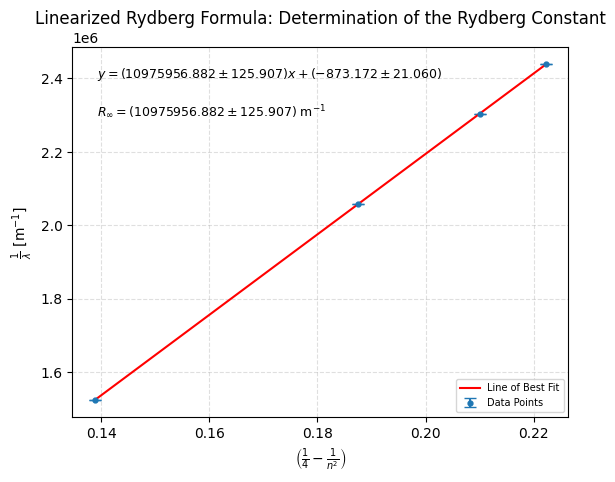

In [59]:
# Defining the model function
def linear(x,m,c):
  return m*x + c

# Fitting the model to the data
popt, pcov = curve_fit(linear, x, y, sigma=y_error, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))   # Uncertainty of the parameters

# Printing out the Relevent Optimal parameter (Gradient==Rydberg Contant)
print(f"The Rydberg constant is:{popt[0]:.3f} ± {perr[0]:.3f} Å")
print(f"The Y-intercept is:{popt[1]:.3f} ± {perr[1]:.3f} Å")

# Visualising the model
x_fit = np.linspace(min(x), max(x), 10000)
y_fit = np.array(linear(x_fit,popt[0], popt [1]))

# Ploting the data and the model
plt.errorbar(x, y, yerr=y_error, fmt='o',capsize=4.5, markersize=3.5, label ="Data Points")   # Plotting the errorbars
plt.plot(x_fit,y_fit, "r", label = "Line of Best Fit")    # Ploting the line of best fit
plt.grid(True, linestyle ="--" ,alpha=0.4)
plt.title("Linearized Rydberg Formula: Determination of the Rydberg Constant")
plt.xlabel(r'$\left(\frac{1}{4} - \frac{1}{n^{2}}\right)$')
plt.ylabel(r'$\frac{1}{\lambda}$ [m$^{-1}$]')
plt.legend(fontsize= 7)

# Add equation and result text box
equation_text = f'$y = ({popt[0]:.3f} \\pm {perr[0]:.3f})x + ({popt[1]:.3f} \\pm {perr[1]:.3f})$'
rydberg_text = f'$R_\\infty = ({popt[0]:.3f} \\pm {perr[0]:.3f})$ m$^{{-1}}$'

plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=9, va='top')
plt.text(0.05, 0.85, rydberg_text, transform=plt.gca().transAxes, fontsize=9, va='top')

#plt.savefig("Rydberg Formula.png")
plt.show()